# Dataset

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv(r'C:\Code_AI\AIO_Code\Module4\Sum\heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# KNN

In [ ]:
X = data.drop(columns='target', axis=1)
y = data['target']

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
classifier = KNeighborsClassifier(
    n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2,metric='minkowski'
) 
classifier.fit(X_train, y_train)


y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)

y_pred_test = classifier.predict(X_test)
cm_test = confusion_matrix(y_test, y_pred_test)

# Print results
print("Training Confusion Matrix:")
print(cm_train)
print("\nTesting Confusion Matrix:")
print(cm_test)


Training Confusion Matrix:
[[371  26]
 [ 37 386]]

Testing Confusion Matrix:
[[74 28]
 [27 76]]


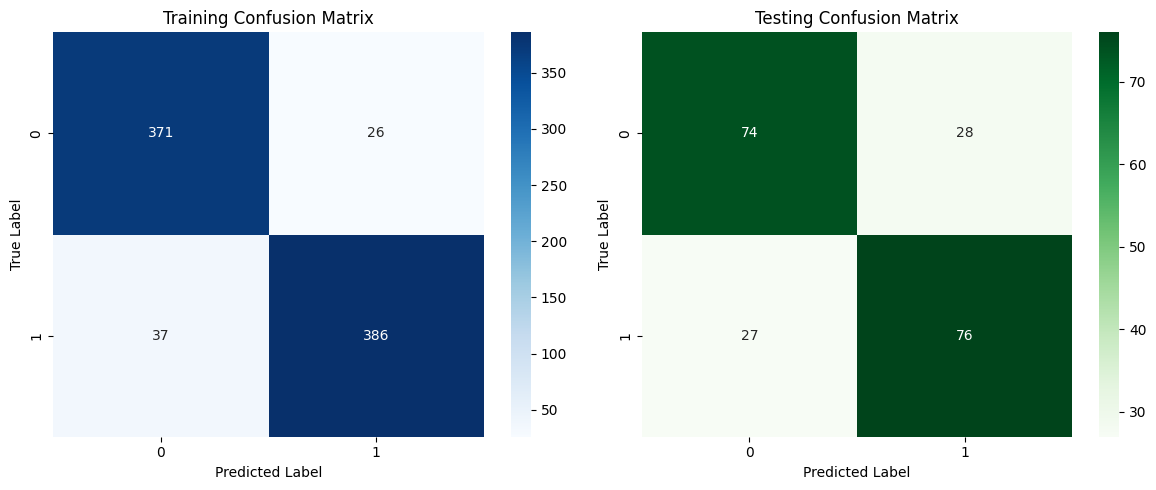

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Training Confusion Matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Testing Confusion Matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Testing Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

# Generate and print the report for the training set
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train))

print("-" * 50)

# Generate and print the report for the testing set
print("\nTesting Classification Report:")
print(classification_report(y_test, y_pred_test))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       397
           1       0.94      0.91      0.92       423

    accuracy                           0.92       820
   macro avg       0.92      0.92      0.92       820
weighted avg       0.92      0.92      0.92       820

--------------------------------------------------

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       102
           1       0.73      0.74      0.73       103

    accuracy                           0.73       205
   macro avg       0.73      0.73      0.73       205
weighted avg       0.73      0.73      0.73       205



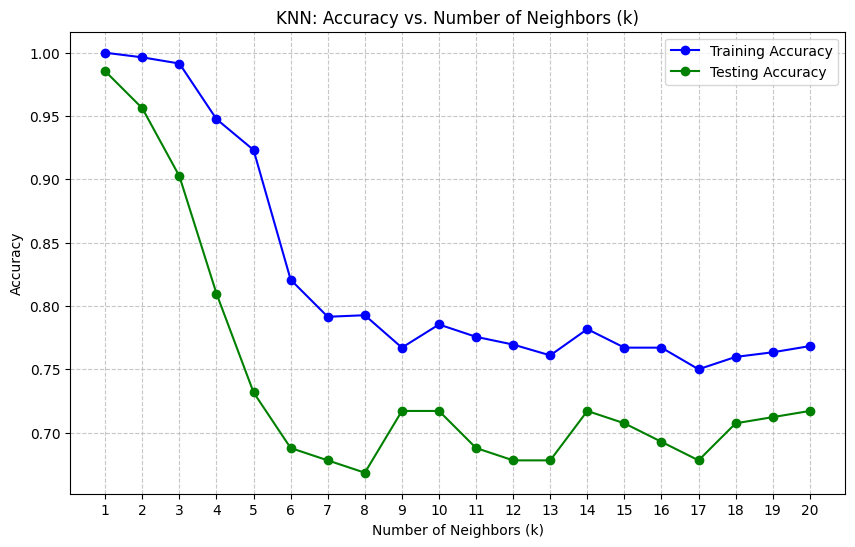

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Lists to store the accuracies
train_accuracies = []
test_accuracies = []

# Define the range of k values we want to test
k_values = range(1, 21)

for k in k_values:
    # 1. Initialize the model with the current k value
    knn = KNeighborsClassifier(
        n_neighbors=k, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski'
    )
    
    # 2. Fit the model
    knn.fit(X_train, y_train)
    
    # 3. Calculate and store Training Accuracy
    train_preds = knn.predict(X_train)
    train_accuracies.append(accuracy_score(y_train, train_preds))
    
    # 4. Calculate and store Testing Accuracy
    test_preds = knn.predict(X_test)
    test_accuracies.append(accuracy_score(y_test, test_preds))

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(k_values, test_accuracies, label='Testing Accuracy', marker='o', color='green')

plt.title('KNN: Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values) # Ensure every k value is labeled on the x-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier

# Define model
classifier = DecisionTreeClassifier(
    criterion='gini', max_depth=10, min_samples_split=2,random_state=42
)
classifier.fit(X_train, y_train)


y_pred_train = classifier.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)

y_pred_test = classifier.predict(X_test)
cm_test = confusion_matrix(y_test, y_pred_test)

# Print results
print("Training Confusion Matrix:")
print(cm_train)
print("\nTesting Confusion Matrix:")
print(cm_test)

Training Confusion Matrix:
[[397   0]
 [  0 423]]

Testing Confusion Matrix:
[[102   0]
 [  3 100]]
